In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

df = pd.read_excel("task2_cleaned_weather_data.xlsx")
df["time"] = pd.to_datetime(df["time"])

numeric_cols = [
    "temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
    "precipitation_sum", "windspeed_10m_max", "relative_humidity_2m_mean"
]

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded: 1830 rows × 13 columns


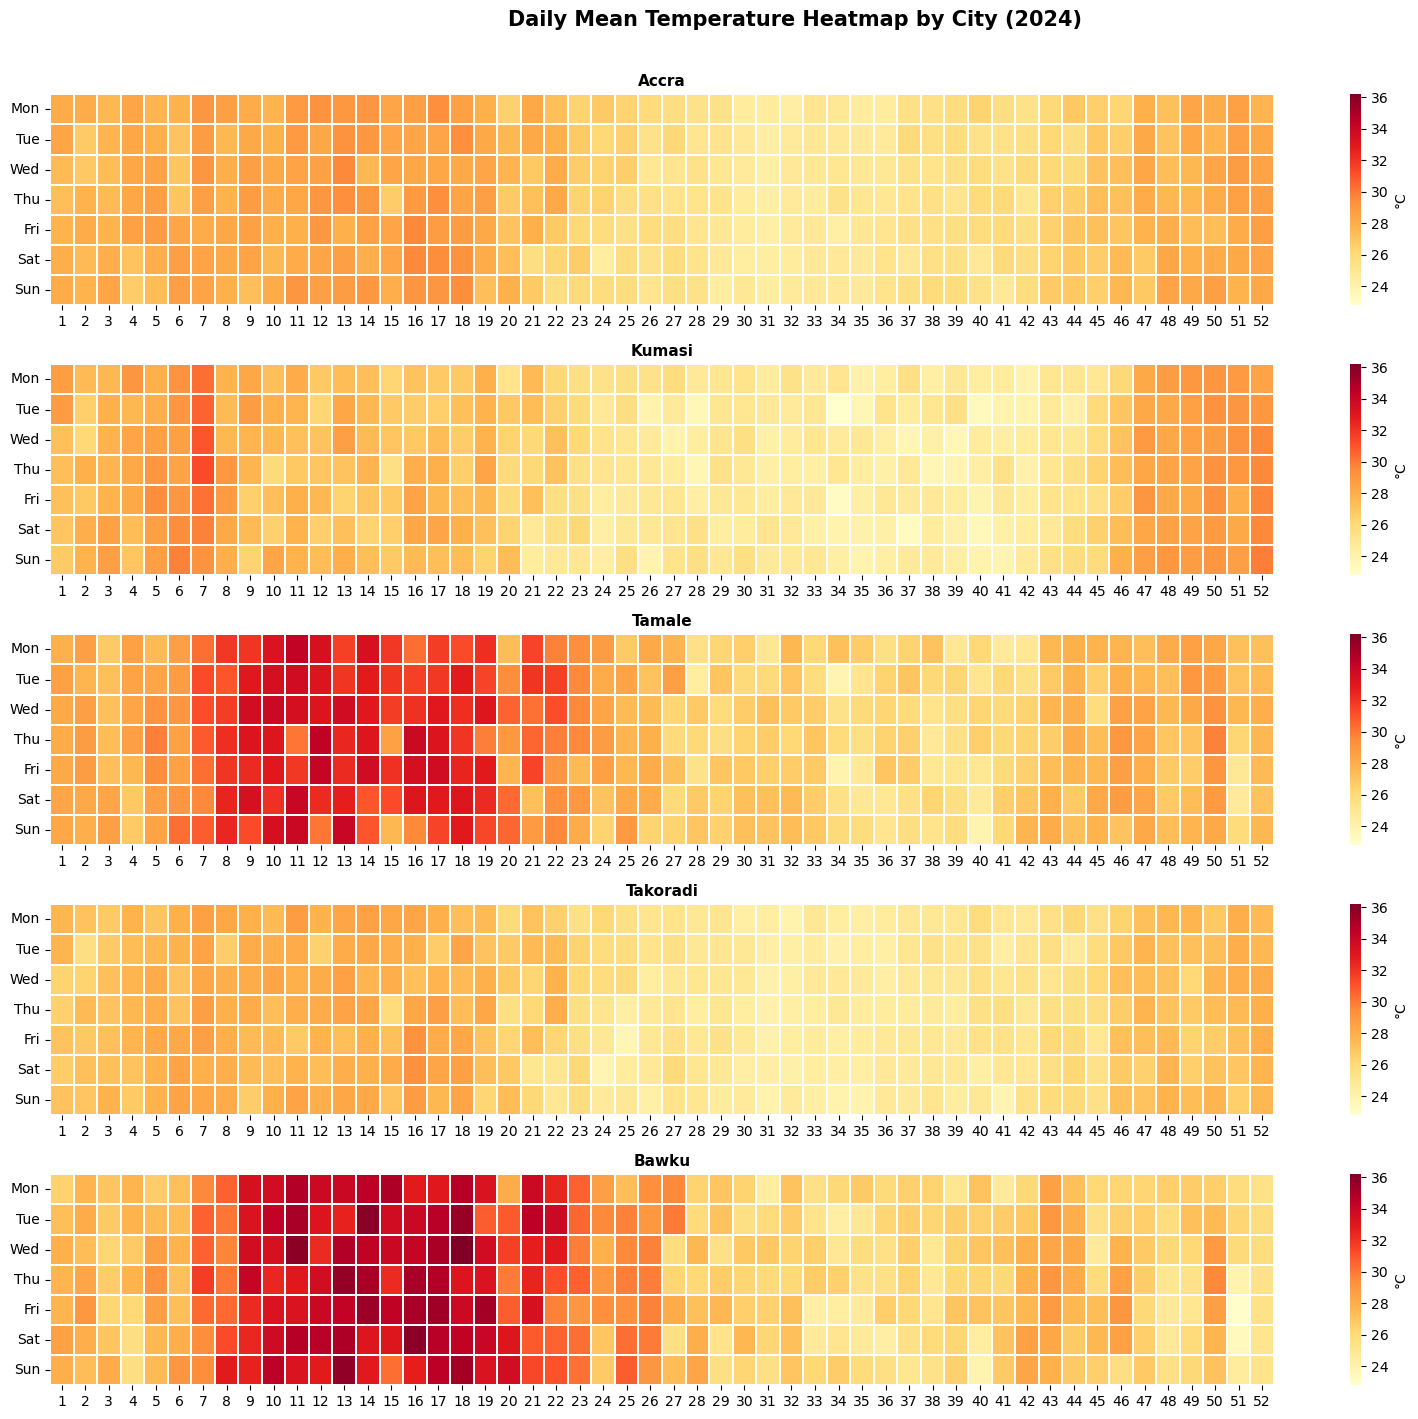

In [2]:
cities_list = df["city"].unique()
fig, axes = plt.subplots(len(cities_list), 1, figsize=(16, 14))
fig.suptitle("Daily Mean Temperature Heatmap by City (2024)", 
             fontsize=15, fontweight='bold', y=1.01)

for ax, city in zip(axes, cities_list):
    city_df = df[df["city"] == city].copy()
    city_df["week"] = city_df["time"].dt.isocalendar().week.astype(int)
    city_df["dayofweek"] = city_df["time"].dt.dayofweek

    pivot = city_df.pivot_table(index="dayofweek", columns="week", 
                                 values="temperature_2m_mean")

    sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.3,
                linecolor='white', cbar_kws={"label": "°C"},
                vmin=df["temperature_2m_mean"].min(),
                vmax=df["temperature_2m_mean"].max())
    ax.set_title(city, fontweight='bold', fontsize=11)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)

plt.tight_layout()
plt.savefig("chart4_1_temperature_calendar.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\pnalh\AppData\Local\Temp\ipykernel_8024\2491700607.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="city", y="precipitation_sum",


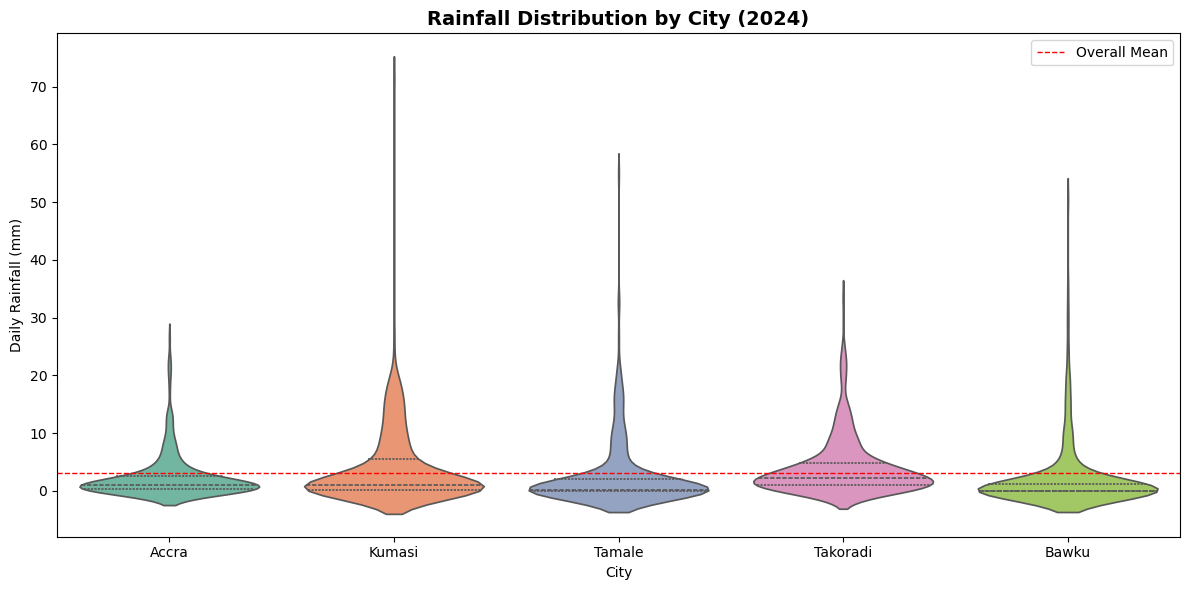

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=df, x="city", y="precipitation_sum", 
               palette="Set2", inner="quartile", ax=ax)

ax.set_title("Rainfall Distribution by City (2024)", 
             fontsize=14, fontweight='bold')
ax.set_xlabel("City")
ax.set_ylabel("Daily Rainfall (mm)")
ax.axhline(df["precipitation_sum"].mean(), color='red', 
           linestyle='--', linewidth=1, label=f'Overall Mean')
ax.legend()

plt.tight_layout()
plt.savefig("chart4_2_rainfall_violin.png", dpi=150, bbox_inches='tight')
plt.show()

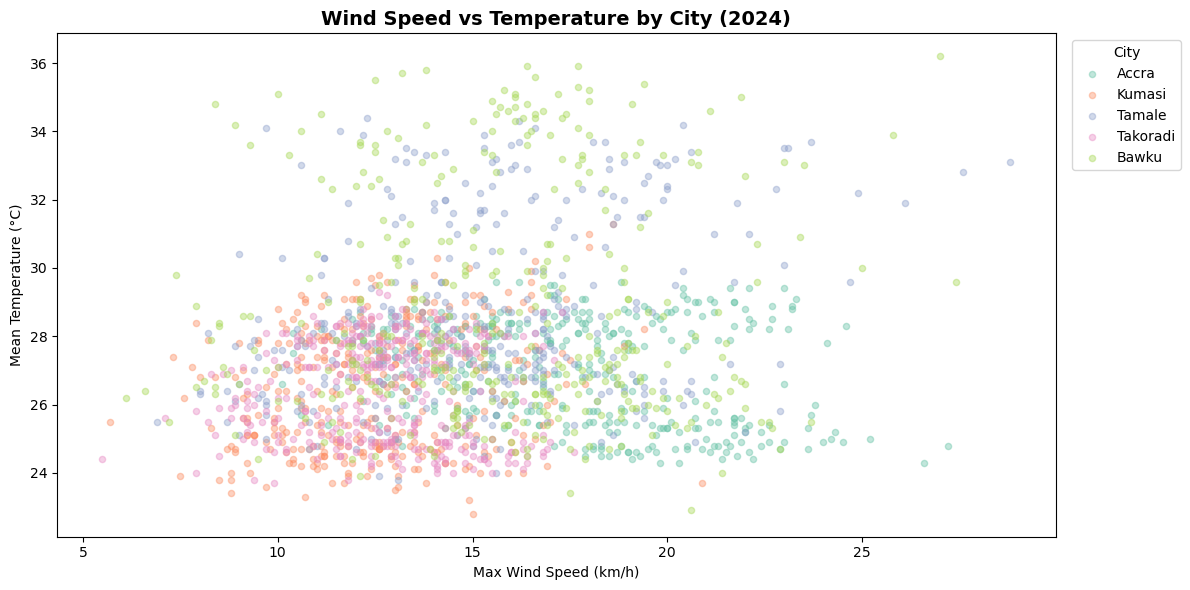

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette("Set2", len(df["city"].unique()))
city_color = dict(zip(df["city"].unique(), colors))

for city in df["city"].unique():
    city_df = df[df["city"] == city]
    ax.scatter(city_df["windspeed_10m_max"], 
               city_df["temperature_2m_mean"],
               label=city, alpha=0.4, s=20,
               color=city_color[city])

ax.set_xlabel("Max Wind Speed (km/h)")
ax.set_ylabel("Mean Temperature (°C)")
ax.set_title("Wind Speed vs Temperature by City (2024)", 
             fontsize=14, fontweight='bold')
ax.legend(title="City", bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig("chart4_3_wind_vs_temp.png", dpi=150, bbox_inches='tight')
plt.show()

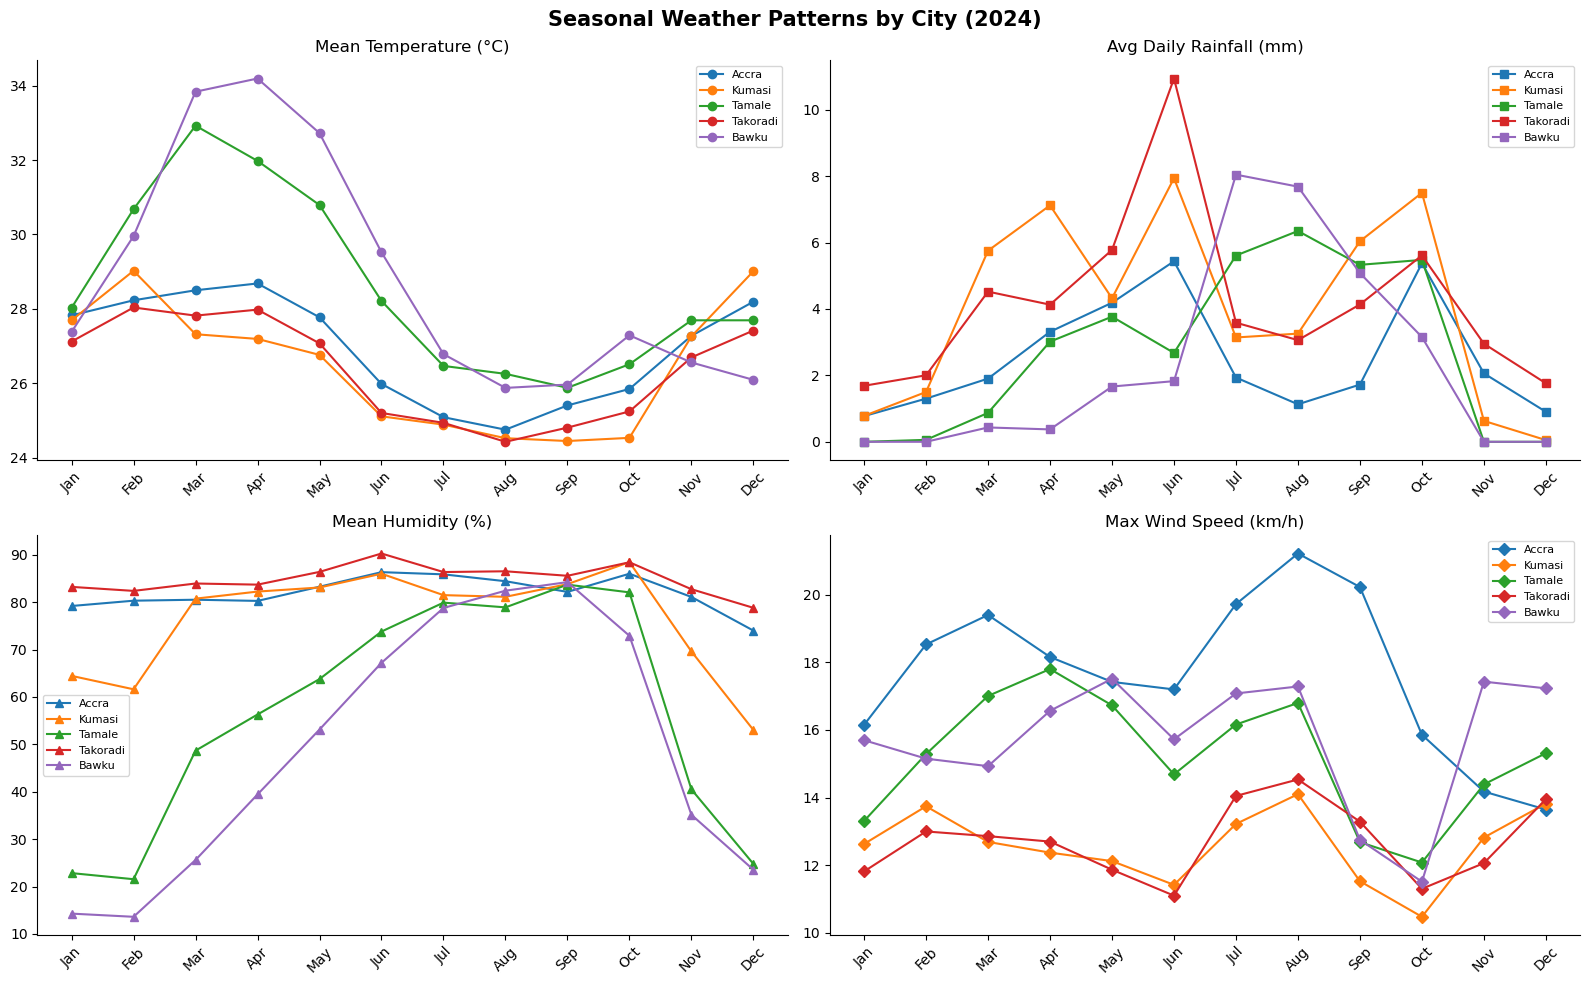

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Seasonal Weather Patterns by City (2024)", 
             fontsize=15, fontweight='bold')

monthly = df.groupby(["month", "city"])[numeric_cols].mean().reset_index()

# Top-left: Mean Temperature
for city in df["city"].unique():
    d = monthly[monthly["city"] == city]
    axes[0,0].plot(d["month"], d["temperature_2m_mean"], marker='o', label=city)
axes[0,0].set_title("Mean Temperature (°C)")
axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels(month_labels, rotation=45)
axes[0,0].legend(fontsize=8)

# Top-right: Precipitation
for city in df["city"].unique():
    d = monthly[monthly["city"] == city]
    axes[0,1].plot(d["month"], d["precipitation_sum"], marker='s', label=city)
axes[0,1].set_title("Avg Daily Rainfall (mm)")
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(month_labels, rotation=45)
axes[0,1].legend(fontsize=8)

# Bottom-left: Humidity
for city in df["city"].unique():
    d = monthly[monthly["city"] == city]
    axes[1,0].plot(d["month"], d["relative_humidity_2m_mean"], marker='^', label=city)
axes[1,0].set_title("Mean Humidity (%)")
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(month_labels, rotation=45)
axes[1,0].legend(fontsize=8)

# Bottom-right: Wind Speed
for city in df["city"].unique():
    d = monthly[monthly["city"] == city]
    axes[1,1].plot(d["month"], d["windspeed_10m_max"], marker='D', label=city)
axes[1,1].set_title("Max Wind Speed (km/h)")
axes[1,1].set_xticks(range(1,13))
axes[1,1].set_xticklabels(month_labels, rotation=45)
axes[1,1].legend(fontsize=8)

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("chart4_4_seasonal_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()